# IMPORTO LIBRERIE E DATI OPEN_METEO

In [1]:
from itertools import combinations
import matplotlib.pyplot as plt
import os
import pandas as pd

In [2]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
from pathlib import Path

Scarico i dati da qui https://open-meteo.com/en/docs/historical-weather-api, posso scegliere se scaricare variabili in formato giornaliero o orario, scelgo di scaricare tutte le variabili presenti in formato giornaliero.

Il codice viene proposto interamente dal sito una volta specificate le variabili richieste

In [3]:
#!pip install openmeteo_requests requests_cache retry_requests

In [4]:
cache_session = requests_cache.CachedSession("../data/.cache", expire_after=-1)
#cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 44.4938,
	"longitude": 11.3387,
	"start_date": "2024-01-01",
	"end_date": "2025-12-31",
	"daily": ["weather_code", "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min", "apparent_temperature_mean", "apparent_temperature_max", "apparent_temperature_min", "wind_speed_10m_max", "wind_gusts_10m_max", "wind_direction_10m_dominant", "shortwave_radiation_sum", "et0_fao_evapotranspiration", "sunrise", "sunset", "daylight_duration", "sunshine_duration", "precipitation_sum", "rain_sum", "snowfall_sum", "precipitation_hours", "cloud_cover_mean", "cloud_cover_max", "cloud_cover_min", "dew_point_2m_mean", "dew_point_2m_max", "dew_point_2m_min", "wet_bulb_temperature_2m_mean", "wet_bulb_temperature_2m_max", "wet_bulb_temperature_2m_min", "vapour_pressure_deficit_max", "soil_moisture_0_to_7cm_mean", "soil_moisture_0_to_100cm_mean", "soil_moisture_28_to_100cm_mean", "soil_moisture_7_to_28cm_mean", "soil_temperature_0_to_100cm_mean", "soil_temperature_0_to_7cm_mean", "soil_temperature_28_to_100cm_mean", "soil_temperature_7_to_28cm_mean", "et0_fao_evapotranspiration_sum", "relative_humidity_2m_mean", "relative_humidity_2m_max", "snowfall_water_equivalent_sum", "pressure_msl_mean", "relative_humidity_2m_min", "pressure_msl_max", "pressure_msl_min", "surface_pressure_mean", "surface_pressure_max", "surface_pressure_min", "winddirection_10m_dominant", "wind_gusts_10m_mean", "wind_speed_10m_mean", "wind_gusts_10m_min", "wind_speed_10m_min"],
	"timezone": "Europe/London",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_weather_code = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_mean = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(2).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(3).ValuesAsNumpy()
daily_apparent_temperature_mean = daily.Variables(4).ValuesAsNumpy()
daily_apparent_temperature_max = daily.Variables(5).ValuesAsNumpy()
daily_apparent_temperature_min = daily.Variables(6).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(7).ValuesAsNumpy()
daily_wind_gusts_10m_max = daily.Variables(8).ValuesAsNumpy()
daily_wind_direction_10m_dominant = daily.Variables(9).ValuesAsNumpy()
daily_shortwave_radiation_sum = daily.Variables(10).ValuesAsNumpy()
daily_et0_fao_evapotranspiration = daily.Variables(11).ValuesAsNumpy()
daily_sunrise = daily.Variables(12).ValuesInt64AsNumpy()
daily_sunset = daily.Variables(13).ValuesInt64AsNumpy()
daily_daylight_duration = daily.Variables(14).ValuesAsNumpy()
daily_sunshine_duration = daily.Variables(15).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(16).ValuesAsNumpy()
daily_rain_sum = daily.Variables(17).ValuesAsNumpy()
daily_snowfall_sum = daily.Variables(18).ValuesAsNumpy()
daily_precipitation_hours = daily.Variables(19).ValuesAsNumpy()
daily_cloud_cover_mean = daily.Variables(20).ValuesAsNumpy()
daily_cloud_cover_max = daily.Variables(21).ValuesAsNumpy()
daily_cloud_cover_min = daily.Variables(22).ValuesAsNumpy()
daily_dew_point_2m_mean = daily.Variables(23).ValuesAsNumpy()
daily_dew_point_2m_max = daily.Variables(24).ValuesAsNumpy()
daily_dew_point_2m_min = daily.Variables(25).ValuesAsNumpy()
daily_wet_bulb_temperature_2m_mean = daily.Variables(26).ValuesAsNumpy()
daily_wet_bulb_temperature_2m_max = daily.Variables(27).ValuesAsNumpy()
daily_wet_bulb_temperature_2m_min = daily.Variables(28).ValuesAsNumpy()
daily_vapour_pressure_deficit_max = daily.Variables(29).ValuesAsNumpy()
daily_soil_moisture_0_to_7cm_mean = daily.Variables(30).ValuesAsNumpy()
daily_soil_moisture_0_to_100cm_mean = daily.Variables(31).ValuesAsNumpy()
daily_soil_moisture_28_to_100cm_mean = daily.Variables(32).ValuesAsNumpy()
daily_soil_moisture_7_to_28cm_mean = daily.Variables(33).ValuesAsNumpy()
daily_soil_temperature_0_to_100cm_mean = daily.Variables(34).ValuesAsNumpy()
daily_soil_temperature_0_to_7cm_mean = daily.Variables(35).ValuesAsNumpy()
daily_soil_temperature_28_to_100cm_mean = daily.Variables(36).ValuesAsNumpy()
daily_soil_temperature_7_to_28cm_mean = daily.Variables(37).ValuesAsNumpy()
daily_et0_fao_evapotranspiration_sum = daily.Variables(38).ValuesAsNumpy()
daily_relative_humidity_2m_mean = daily.Variables(39).ValuesAsNumpy()
daily_relative_humidity_2m_max = daily.Variables(40).ValuesAsNumpy()
daily_snowfall_water_equivalent_sum = daily.Variables(41).ValuesAsNumpy()
daily_pressure_msl_mean = daily.Variables(42).ValuesAsNumpy()
daily_relative_humidity_2m_min = daily.Variables(43).ValuesAsNumpy()
daily_pressure_msl_max = daily.Variables(44).ValuesAsNumpy()
daily_pressure_msl_min = daily.Variables(45).ValuesAsNumpy()
daily_surface_pressure_mean = daily.Variables(46).ValuesAsNumpy()
daily_surface_pressure_max = daily.Variables(47).ValuesAsNumpy()
daily_surface_pressure_min = daily.Variables(48).ValuesAsNumpy()
daily_winddirection_10m_dominant = daily.Variables(49).ValuesAsNumpy()
daily_wind_gusts_10m_mean = daily.Variables(50).ValuesAsNumpy()
daily_wind_speed_10m_mean = daily.Variables(51).ValuesAsNumpy()
daily_wind_gusts_10m_min = daily.Variables(52).ValuesAsNumpy()
daily_wind_speed_10m_min = daily.Variables(53).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["weather_code"] = daily_weather_code
daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["apparent_temperature_mean"] = daily_apparent_temperature_mean
daily_data["apparent_temperature_max"] = daily_apparent_temperature_max
daily_data["apparent_temperature_min"] = daily_apparent_temperature_min
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
daily_data["wind_direction_10m_dominant"] = daily_wind_direction_10m_dominant
daily_data["shortwave_radiation_sum"] = daily_shortwave_radiation_sum
daily_data["et0_fao_evapotranspiration"] = daily_et0_fao_evapotranspiration
daily_data["sunrise"] = daily_sunrise
daily_data["sunset"] = daily_sunset
daily_data["daylight_duration"] = daily_daylight_duration
daily_data["sunshine_duration"] = daily_sunshine_duration
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["rain_sum"] = daily_rain_sum
daily_data["snowfall_sum"] = daily_snowfall_sum
daily_data["precipitation_hours"] = daily_precipitation_hours
daily_data["cloud_cover_mean"] = daily_cloud_cover_mean
daily_data["cloud_cover_max"] = daily_cloud_cover_max
daily_data["cloud_cover_min"] = daily_cloud_cover_min
daily_data["dew_point_2m_mean"] = daily_dew_point_2m_mean
daily_data["dew_point_2m_max"] = daily_dew_point_2m_max
daily_data["dew_point_2m_min"] = daily_dew_point_2m_min
daily_data["wet_bulb_temperature_2m_mean"] = daily_wet_bulb_temperature_2m_mean
daily_data["wet_bulb_temperature_2m_max"] = daily_wet_bulb_temperature_2m_max
daily_data["wet_bulb_temperature_2m_min"] = daily_wet_bulb_temperature_2m_min
daily_data["vapour_pressure_deficit_max"] = daily_vapour_pressure_deficit_max
daily_data["soil_moisture_0_to_7cm_mean"] = daily_soil_moisture_0_to_7cm_mean
daily_data["soil_moisture_0_to_100cm_mean"] = daily_soil_moisture_0_to_100cm_mean
daily_data["soil_moisture_28_to_100cm_mean"] = daily_soil_moisture_28_to_100cm_mean
daily_data["soil_moisture_7_to_28cm_mean"] = daily_soil_moisture_7_to_28cm_mean
daily_data["soil_temperature_0_to_100cm_mean"] = daily_soil_temperature_0_to_100cm_mean
daily_data["soil_temperature_0_to_7cm_mean"] = daily_soil_temperature_0_to_7cm_mean
daily_data["soil_temperature_28_to_100cm_mean"] = daily_soil_temperature_28_to_100cm_mean
daily_data["soil_temperature_7_to_28cm_mean"] = daily_soil_temperature_7_to_28cm_mean
daily_data["et0_fao_evapotranspiration_sum"] = daily_et0_fao_evapotranspiration_sum
daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
daily_data["relative_humidity_2m_max"] = daily_relative_humidity_2m_max
daily_data["snowfall_water_equivalent_sum"] = daily_snowfall_water_equivalent_sum
daily_data["pressure_msl_mean"] = daily_pressure_msl_mean
daily_data["relative_humidity_2m_min"] = daily_relative_humidity_2m_min
daily_data["pressure_msl_max"] = daily_pressure_msl_max
daily_data["pressure_msl_min"] = daily_pressure_msl_min
daily_data["surface_pressure_mean"] = daily_surface_pressure_mean
daily_data["surface_pressure_max"] = daily_surface_pressure_max
daily_data["surface_pressure_min"] = daily_surface_pressure_min
daily_data["winddirection_10m_dominant"] = daily_winddirection_10m_dominant
daily_data["wind_gusts_10m_mean"] = daily_wind_gusts_10m_mean
daily_data["wind_speed_10m_mean"] = daily_wind_speed_10m_mean
daily_data["wind_gusts_10m_min"] = daily_wind_gusts_10m_min
daily_data["wind_speed_10m_min"] = daily_wind_speed_10m_min

daily_df = pd.DataFrame(data = daily_data)
daily_df.head()


Coordinates: 44.46397018432617°N 11.31901741027832°E
Elevation: 74.0 m asl
Timezone: b'Europe/London'b'GMT+1'
Timezone difference to GMT+0: 3600s


,date,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,wind_speed_10m_max,wind_gusts_10m_max,...,pressure_msl_max,pressure_msl_min,surface_pressure_mean,surface_pressure_max,surface_pressure_min,winddirection_10m_dominant,wind_gusts_10m_mean,wind_speed_10m_mean,wind_gusts_10m_min,wind_speed_10m_min
0,2024-01-01 00:00:00+00:00,63.0,7.725000,12.80,4.10,5.472923,10.320510,1.490191,18.671474,37.439999,...,1016.900024,1009.400024,1004.202942,1007.699341,1000.522766,279.229797,18.225000,8.328450,9.00,3.096837
1,2024-01-02 00:00:00+00:00,3.0,4.879167,8.20,1.95,2.537657,5.896303,-0.901211,8.669949,21.240000,...,1017.400024,1010.700012,1005.824158,1008.118286,1001.626770,325.491394,11.549999,5.648446,6.48,2.595997
2,2024-01-03 00:00:00+00:00,3.0,6.289584,10.75,3.40,4.131104,8.637382,0.554647,10.594036,23.039999,...,1010.900024,1006.599976,1000.068848,1001.791077,997.560486,337.432953,13.919999,6.163117,6.84,1.018234
3,2024-01-04 00:00:00+00:00,3.0,9.206251,16.60,3.25,6.835380,15.037155,0.930140,16.781561,30.239998,...,1011.299988,1006.000000,1000.189880,1002.280579,996.931763,228.068130,17.639999,8.968826,7.20,3.240000
4,2024-01-05 00:00:00+00:00,53.0,7.510416,10.90,3.10,5.056265,8.676153,0.474006,17.388409,31.319998,...,1012.000000,1000.099976,998.216553,1002.871399,991.246033,97.402382,18.869999,9.785817,5.04,1.609969


In [5]:
daily_df.shape

(731, 55)

# CONTROLLO DUPLICATI E MISSING

Controllo se ci sono righe interamente duplicate

In [6]:
daily_df['flag_dupl'] = daily_df.duplicated(keep=False)
daily_df['flag_dupl'].value_counts()

flag_dupl
False    731
Name: count, dtype: int64

Il numero di False combacia con il numero di righe del df, non ci sono righe duplicate. Elimino il flag creato

In [7]:
daily_df.shape

(731, 56)

In [8]:
daily_df = daily_df.drop(columns = ['flag_dupl'])

In [9]:
daily_df.shape

(731, 55)

----------------------------------------------------------

Controllo se ci sono colonne duplicate

In [10]:
dupes = []
for col1, col2 in combinations(daily_df.columns, 2):
    if daily_df[col1].equals(daily_df[col2]):
        dupes.append((col1, col2))

print(dupes)

[('wind_direction_10m_dominant', 'winddirection_10m_dominant'), ('et0_fao_evapotranspiration', 'et0_fao_evapotranspiration_sum')]


Ci sono due colonne duplicate: 'wind_direction_10m_dominant' e 'et0_fao_evapotranspiration'. Droppo la seconda colonna di entrambe le liste.

In [11]:
daily_df.shape

(731, 55)

In [12]:
daily_df = daily_df.drop(columns = ['winddirection_10m_dominant', 'et0_fao_evapotranspiration_sum'])

In [13]:
daily_df.shape

(731, 53)

---------------------------------------------

Controllo se e quanti missing ci sono per ogni colonna del df

In [14]:
daily_df.isnull().sum().sum()

np.int64(0)

Non ci sono dati mancanti nel df

_________________________________________________________________

Controllo il tipo di informazioni che abbiamo nel dataseet

In [15]:
daily_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype             
---  ------                             --------------  -----             
 0   date                               731 non-null    datetime64[s, UTC]
 1   weather_code                       731 non-null    float32           
 2   temperature_2m_mean                731 non-null    float32           
 3   temperature_2m_max                 731 non-null    float32           
 4   temperature_2m_min                 731 non-null    float32           
 5   apparent_temperature_mean          731 non-null    float32           
 6   apparent_temperature_max           731 non-null    float32           
 7   apparent_temperature_min           731 non-null    float32           
 8   wind_speed_10m_max                 731 non-null    float32           
 9   wind_gusts_10m_max                 731 non-null    float32           
 10  w

In [16]:
daily_df.shape

(731, 53)

------------------------------------------------------------

# MANIPOLAZIONE DELLE VARIABILI

Le colonne 'sunrise' e 'sunset' sono espresse in unità di misura iso8601, indica l'orario di alba e tramonto in secondi a partire dal 1970-01-01. 

L'ho scaricato come integer, trasformo i secondi in datetime leggibile e poi elimino il giorno dalla colonna perchè non ci dà informazioni utilil (il giorno è già indicato nella colonna chiave)

In [17]:
daily_df.sunset.head(2)

0    1704123899
1    1704210354
Name: sunset, dtype: int64

Con dt.time tengo soltanto l'orario, eliminando la parte yyyy-mm-dd. Di conseguenza le due colonne passano da int a object, dato che per essere un datetime è necessario avere l'intero formato


In [18]:
daily_df['sunrise'] = pd.to_datetime(daily_df['sunrise'], unit='s')
daily_df['sunset'] = pd.to_datetime(daily_df['sunset'], unit='s')
#aggiungendo (.dt.time) rimago 

In [19]:
daily_df.sunset.head(2)

0   2024-01-01 15:44:59
1   2024-01-02 15:45:54
Name: sunset, dtype: datetime64[s]

In [20]:
daily_df.sunrise.head(2)

0   2024-01-01 06:50:57
1   2024-01-02 06:51:00
Name: sunrise, dtype: datetime64[s]

Trasformo le colonne sunrise e sunset in minuti passati da 00:00 per poterli plottare contro la colonna date, altrimenti il risultato è una retta con pendenza positiva

In [21]:
daily_df['sunrise_minutes'] = daily_df['sunrise'].dt.hour * 60 + daily_df['sunrise'].dt.minute
daily_df['sunset_minutes'] = daily_df['sunset'].dt.hour * 60 + daily_df['sunset'].dt.minute

In [22]:
daily_df = daily_df.drop(columns = ['sunrise', 'sunset'])

In [23]:
daily_df.shape

(731, 53)

------------------------------------------------------


Voglio modificare la colonna 'date': elimino 'hh-mm-ss + fuso orario' dalle date perchè rindondante e non aggiunge informazioni utili. 

Se elimino hh-mm-ss + fuso orario il valore mi diventa un object, diventa difficile poi matchare i due df. Lascio cosi 

In [24]:
daily_df.date.head()

0   2024-01-01 00:00:00+00:00
1   2024-01-02 00:00:00+00:00
2   2024-01-03 00:00:00+00:00
3   2024-01-04 00:00:00+00:00
4   2024-01-05 00:00:00+00:00
Name: date, dtype: datetime64[s, UTC]

In [25]:
daily_df['date'] = daily_df['date'].dt.tz_localize(None)

In [26]:
daily_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype        
---  ------                             --------------  -----        
 0   date                               731 non-null    datetime64[s]
 1   weather_code                       731 non-null    float32      
 2   temperature_2m_mean                731 non-null    float32      
 3   temperature_2m_max                 731 non-null    float32      
 4   temperature_2m_min                 731 non-null    float32      
 5   apparent_temperature_mean          731 non-null    float32      
 6   apparent_temperature_max           731 non-null    float32      
 7   apparent_temperature_min           731 non-null    float32      
 8   wind_speed_10m_max                 731 non-null    float32      
 9   wind_gusts_10m_max                 731 non-null    float32      
 10  wind_direction_10m_dominant        731 non-null    float32   

-------------------------------------------------------

Raggruppo le variabili per tipologia, per facilitare la feature selection più tardi. 

In [27]:
groups = {  
    'temperature': [
        'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
        'apparent_temperature_mean', 'apparent_temperature_max', 'apparent_temperature_min',
        'wet_bulb_temperature_2m_mean', 'wet_bulb_temperature_2m_max', 'wet_bulb_temperature_2m_min',
        'dew_point_2m_mean', 'dew_point_2m_max', 'dew_point_2m_min'
    ],
    'wind': [
        'wind_speed_10m_mean', 'wind_speed_10m_max', 'wind_speed_10m_min',
        'wind_gusts_10m_mean', 'wind_gusts_10m_max', 'wind_gusts_10m_min',
        'wind_direction_10m_dominant'
    ],
    'precipitation': [
        'precipitation_sum', 'precipitation_hours',
        'rain_sum', 'snowfall_sum', 'snowfall_water_equivalent_sum'
    ],
    'radiation_sunlight': [
        'shortwave_radiation_sum', 'sunshine_duration',
        'daylight_duration', 'sunrise_minutes', 'sunset_minutes'
    ],
    'dew_pressure': [
        'relative_humidity_2m_mean', 'relative_humidity_2m_max', 'relative_humidity_2m_min',
        'vapour_pressure_deficit_max',
        'pressure_msl_mean', 'pressure_msl_max', 'pressure_msl_min',
        'surface_pressure_mean', 'surface_pressure_max', 'surface_pressure_min'
    ],
    'cloud': [
        'cloud_cover_mean', 'cloud_cover_max', 'cloud_cover_min'
    ],
    'soil': [
        'soil_temperature_0_to_7cm_mean', 'soil_temperature_7_to_28cm_mean',
        'soil_temperature_28_to_100cm_mean', 'soil_temperature_0_to_100cm_mean',
        'soil_moisture_0_to_7cm_mean', 'soil_moisture_7_to_28cm_mean',
        'soil_moisture_28_to_100cm_mean', 'soil_moisture_0_to_100cm_mean'
    ],
    'evotraspiration': [
        'et0_fao_evapotranspiration'
    ],
    'others': [
        'weather_code'
    ]
}

In [28]:
daily_df.columns

Index(['date', 'weather_code', 'temperature_2m_mean', 'temperature_2m_max',
       'temperature_2m_min', 'apparent_temperature_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'wind_speed_10m_max', 'wind_gusts_10m_max',
       'wind_direction_10m_dominant', 'shortwave_radiation_sum',
       'et0_fao_evapotranspiration', 'daylight_duration', 'sunshine_duration',
       'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours',
       'cloud_cover_mean', 'cloud_cover_max', 'cloud_cover_min',
       'dew_point_2m_mean', 'dew_point_2m_max', 'dew_point_2m_min',
       'wet_bulb_temperature_2m_mean', 'wet_bulb_temperature_2m_max',
       'wet_bulb_temperature_2m_min', 'vapour_pressure_deficit_max',
       'soil_moisture_0_to_7cm_mean', 'soil_moisture_0_to_100cm_mean',
       'soil_moisture_28_to_100cm_mean', 'soil_moisture_7_to_28cm_mean',
       'soil_temperature_0_to_100cm_mean', 'soil_temperature_0_to_7cm_mean',
       'soil_temperature_28_to_100cm

In [29]:
cols = daily_df.columns.tolist()

# colonne non assegnate
assegnate = [c for g in groups.values() for c in g]
print("Non assegnate:", set(cols) - set(assegnate))

# colonne in più gruppi
assegnate = [c for g in groups.values() for c in g]
print("In più gruppi:", [c for c in assegnate if assegnate.count(c) > 1])

Non assegnate: {'date'}
In più gruppi: []


-----------------------------------------------------------------------------------

La colonna 'weather_code' non ci dà dirette informazioni in formato numerico. Leggendo la legenda su https://www.nodc.noaa.gov/archive/arc0021/0002199/1.1/data/0-data/HTML/WMO-CODE/WMO4677.HTM scelgo di mappare i gruppi di codice che rappresentano condizioni climatiche simili con delle brevi descrizioni in un'altra colonna

In [30]:
daily_df.weather_code.describe()

count    731.000000
mean      28.804379
std       27.259159
min        0.000000
25%        3.000000
50%        3.000000
75%       53.000000
max       75.000000
Name: weather_code, dtype: float64

In [31]:
def map_weather_code(code):
    if code < 10:   return 'clear_or_reduced_visibility'
    if code < 20:   return 'fog_lightning_distant_precip'
    if code < 30:   return 'recent_precip_fog_thunderstorm'
    if code < 40:   return 'duststorm_sandstorm_blowing_snow'
    if code < 50:   return 'fog_or_ice_fog'
    if code < 60:   return 'drizzle'
    if code < 70:   return 'rain'
    return 'solid_precipitation'

daily_df['weather_description'] = daily_df['weather_code'].apply(map_weather_code)

In [32]:
daily_df.weather_description.head()

0                           rain
1    clear_or_reduced_visibility
2    clear_or_reduced_visibility
3    clear_or_reduced_visibility
4                        drizzle
Name: weather_description, dtype: str

Droppo la colonna 'weather_code' numerica

In [33]:
daily_df = daily_df.drop(columns = ['weather_code'])

In [34]:
daily_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype        
---  ------                             --------------  -----        
 0   date                               731 non-null    datetime64[s]
 1   temperature_2m_mean                731 non-null    float32      
 2   temperature_2m_max                 731 non-null    float32      
 3   temperature_2m_min                 731 non-null    float32      
 4   apparent_temperature_mean          731 non-null    float32      
 5   apparent_temperature_max           731 non-null    float32      
 6   apparent_temperature_min           731 non-null    float32      
 7   wind_speed_10m_max                 731 non-null    float32      
 8   wind_gusts_10m_max                 731 non-null    float32      
 9   wind_direction_10m_dominant        731 non-null    float32      
 10  shortwave_radiation_sum            731 non-null    float32   

------------------------------

# CONTROLLO OUTLIERS

In [35]:
#Controllo gruppo per gruppo con degli scatter plot la presenza di outliers
#Gruppi: temperature, wind, precipitation, radiation_sunlight, dew_pressure, cloud, soil, evotraspiration

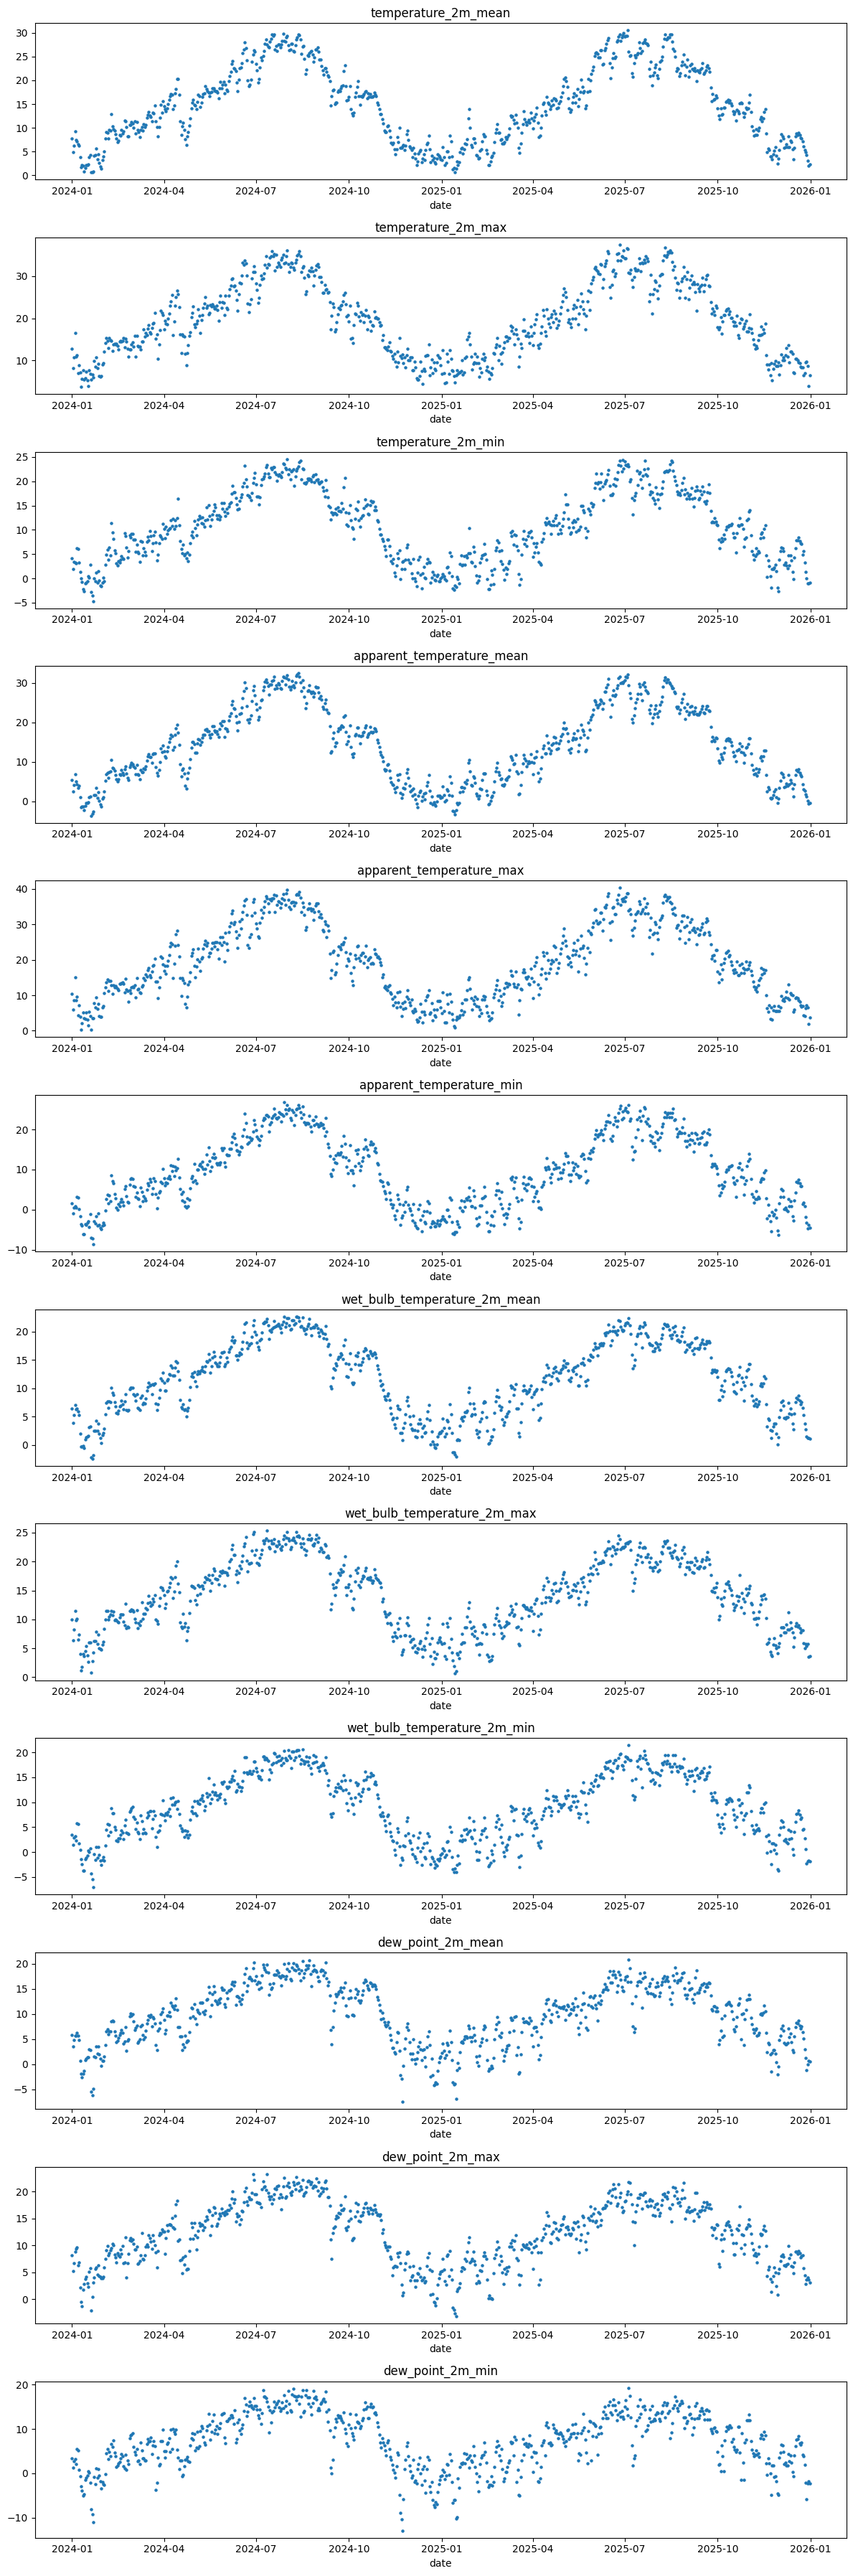

In [36]:
temp_cols = groups['temperature']

fig, axes = plt.subplots(len(temp_cols), 1, figsize=(12, len(temp_cols) * 3))

for i, col in enumerate(temp_cols):
    axes[i].scatter(daily_df['date'], daily_df[col], s=5)
    axes[i].set_title(col)
    axes[i].set_xlabel('date')

plt.tight_layout()
plt.show()

Il gruppo temperatura non presenta outliers

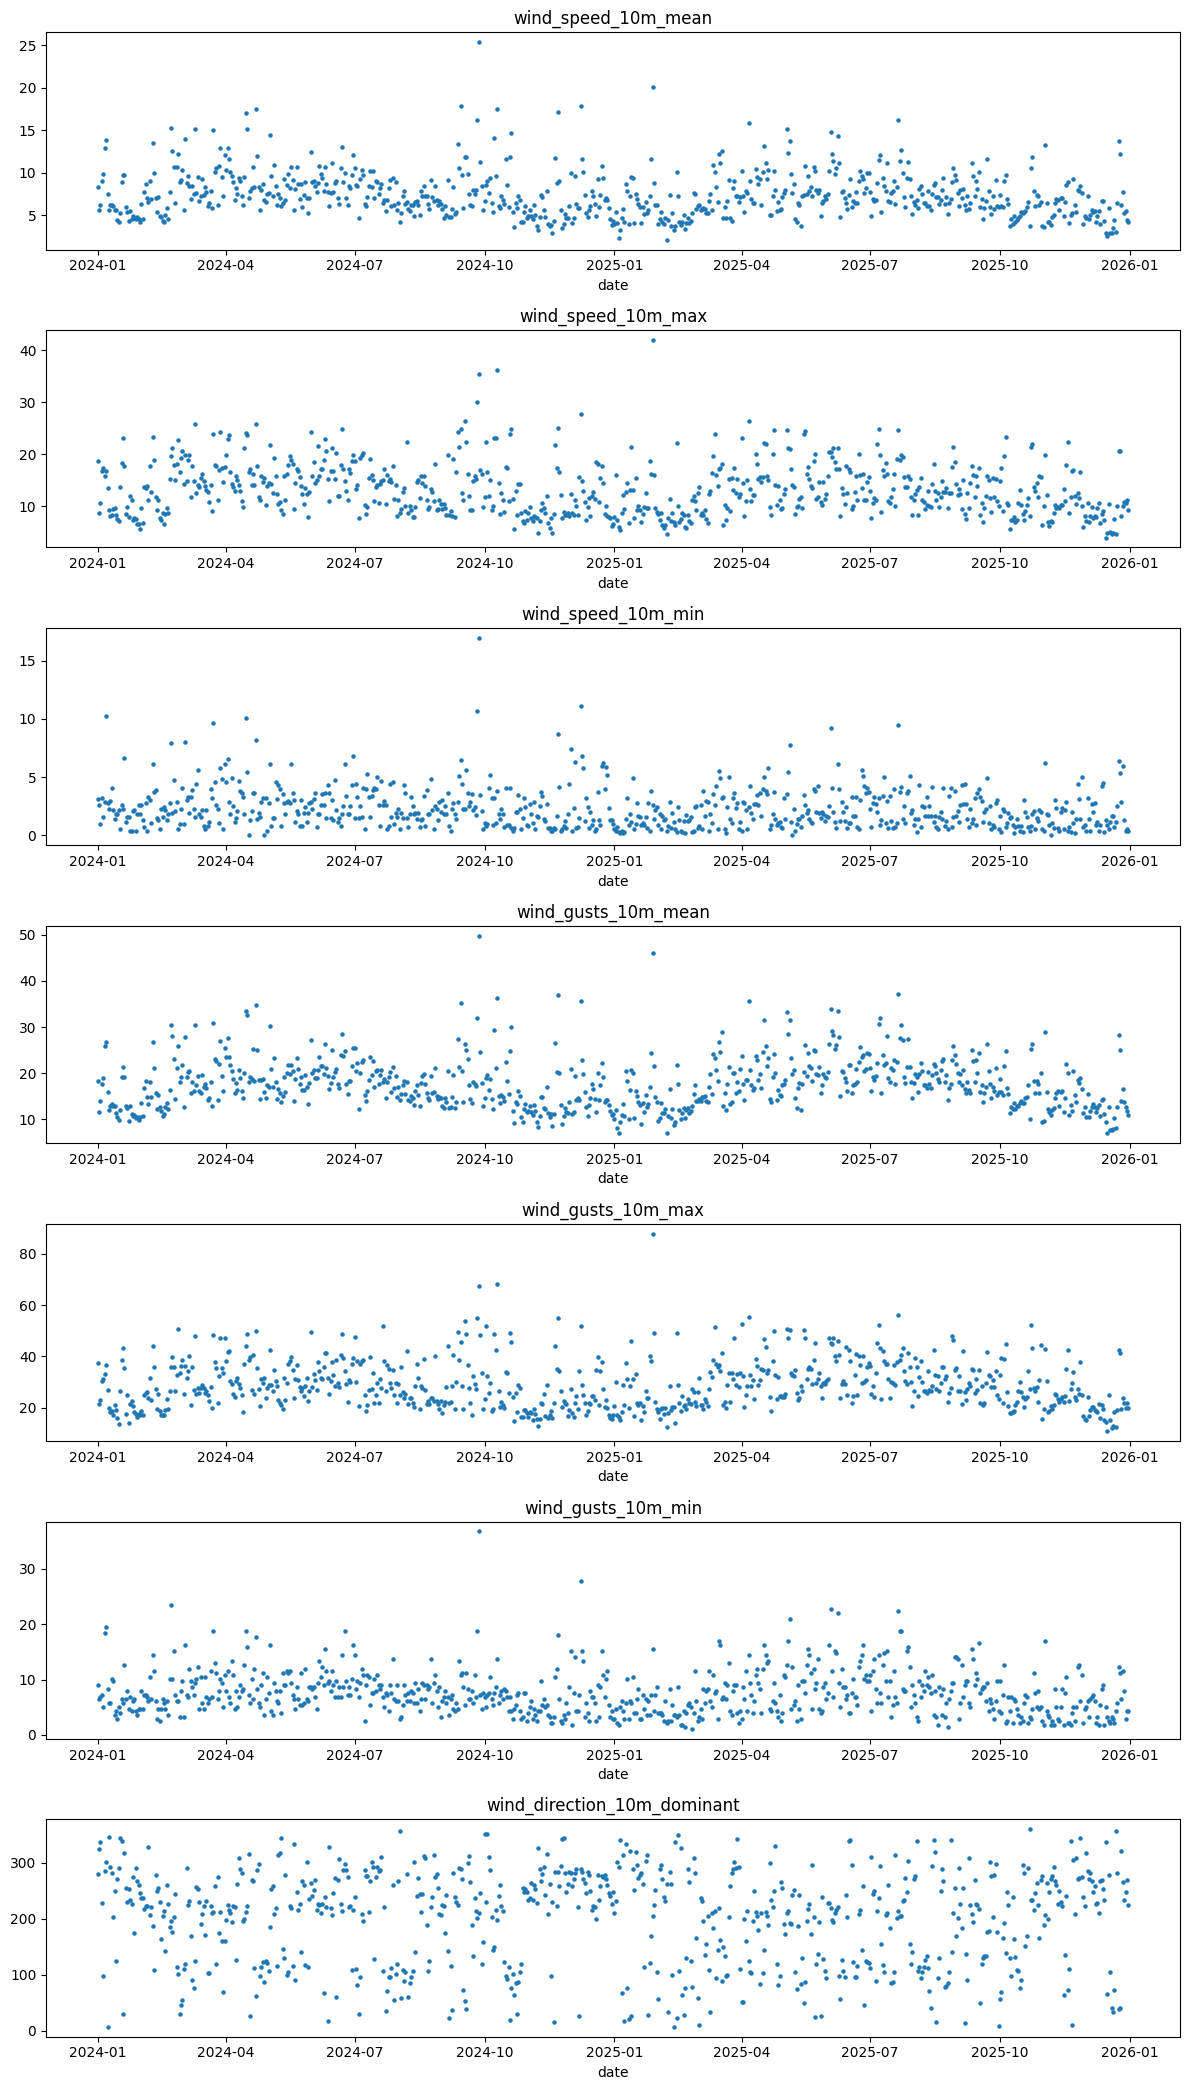

In [37]:
wind_cols = groups['wind']

fig, axes = plt.subplots(len(wind_cols), 1, figsize=(12, len(wind_cols) * 3))

for i, col in enumerate(wind_cols):
    axes[i].scatter(daily_df['date'], daily_df[col], s=5)
    axes[i].set_title(col)
    axes[i].set_xlabel('date')

plt.tight_layout()
plt.show()

La variabile Wind_direction_10m_dominant è molto dispersiva, ritengo che non ha potere predittivo su alcuna variabile, attendo conferme date dalla v-score per poterla droppare

Il gruppo 'wind' presenta uno-due outlier per variabile. 

In [38]:
Q1 = daily_df[groups['wind']].quantile(0.05)
Q3 = daily_df[groups['wind']].quantile(0.95)
IQR = Q3 - Q1

mask = (daily_df[groups['wind']] < (Q1 - IQR)) | (daily_df[groups['wind']] > (Q3 + IQR))

daily_df[['date'] + groups['wind']][mask.any(axis=1)]

,date,wind_speed_10m_mean,wind_speed_10m_max,wind_speed_10m_min,wind_gusts_10m_mean,wind_gusts_10m_max,wind_gusts_10m_min,wind_direction_10m_dominant
270,2024-09-27,25.356628,35.339642,16.956343,49.784996,67.320000,36.719997,211.066330
342,2024-12-08,17.881479,27.722336,11.132385,35.594997,51.839996,27.719999,288.828857
393,2025-01-28,20.050549,41.935364,2.595997,46.020008,87.839996,15.480000,205.157990


Ritengo sia giusto tenerli in quanto non sembrano errori di registrazione dati, solo anomalie climatiche

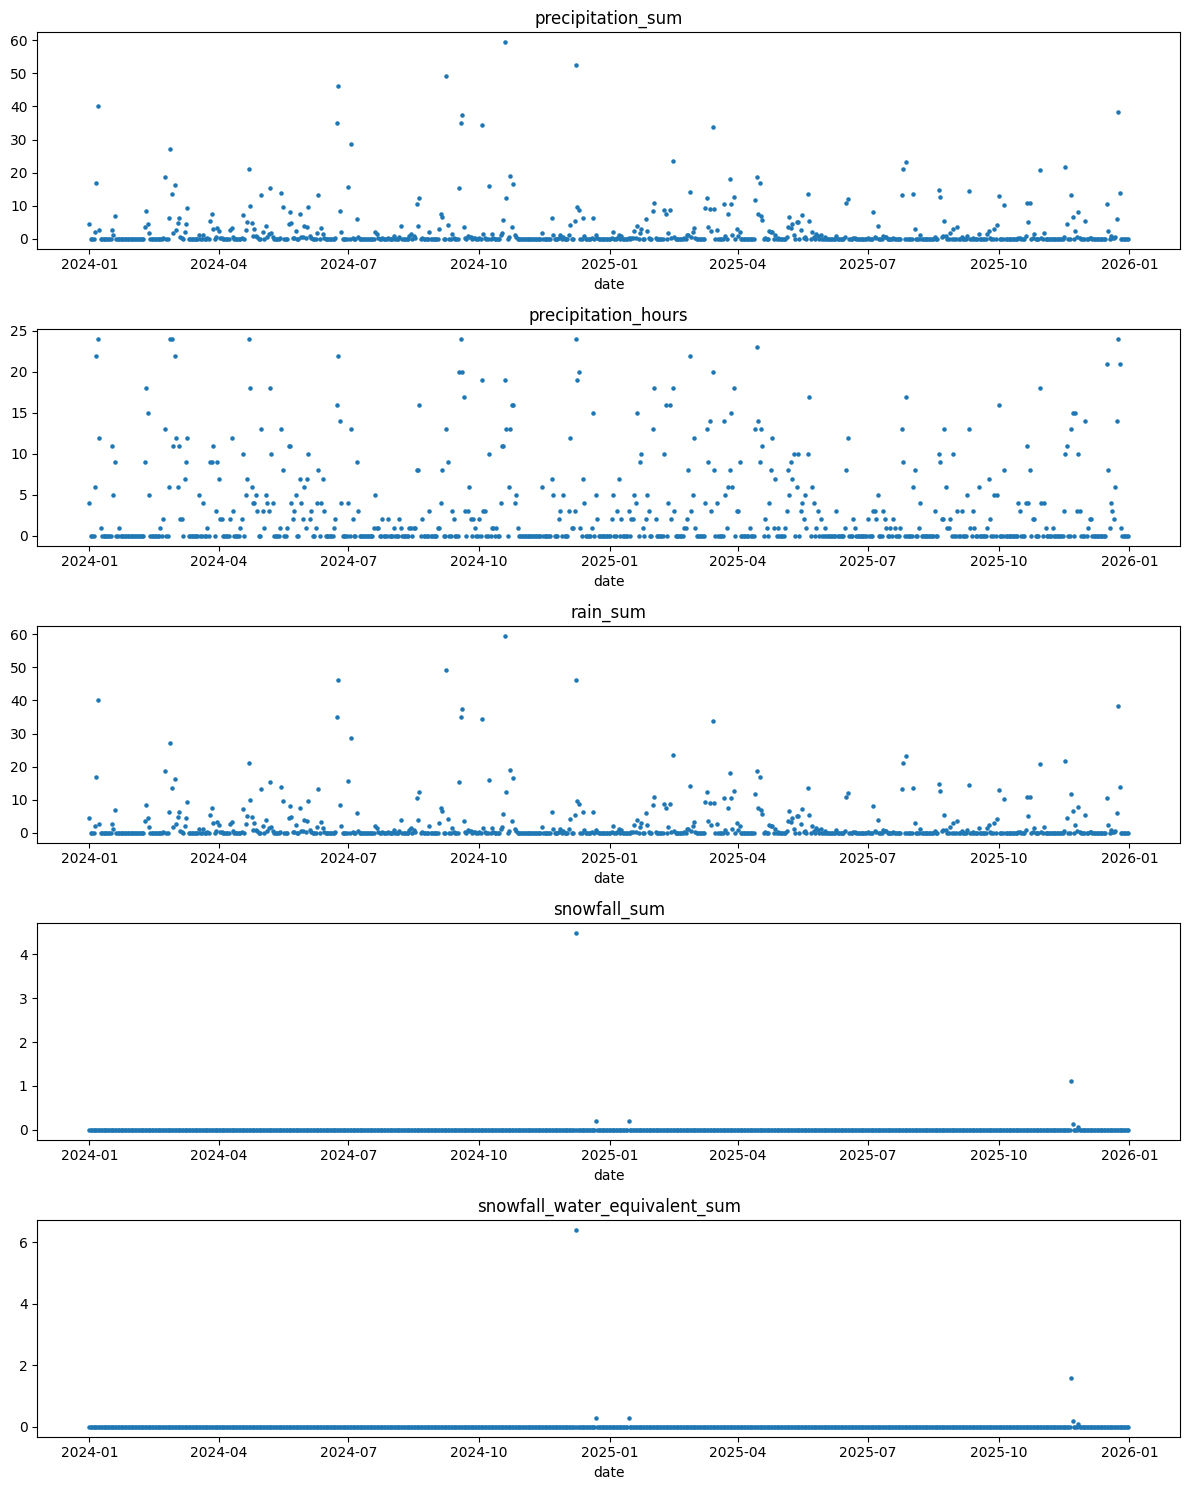

In [39]:
prep_cols = groups['precipitation']

fig, axes = plt.subplots(len(prep_cols), 1, figsize=(12, len(prep_cols) * 3))

for i, col in enumerate(prep_cols):
    axes[i].scatter(daily_df['date'], daily_df[col], s=5)
    axes[i].set_title(col)
    axes[i].set_xlabel('date')

plt.tight_layout()
plt.show()

Le variabili snowfall sono quasi interamente piatte, ritengo che abbiano uno scarso potere predittivo. 
Ci sono valori anomali ma ritengo siano misurazioni corrette

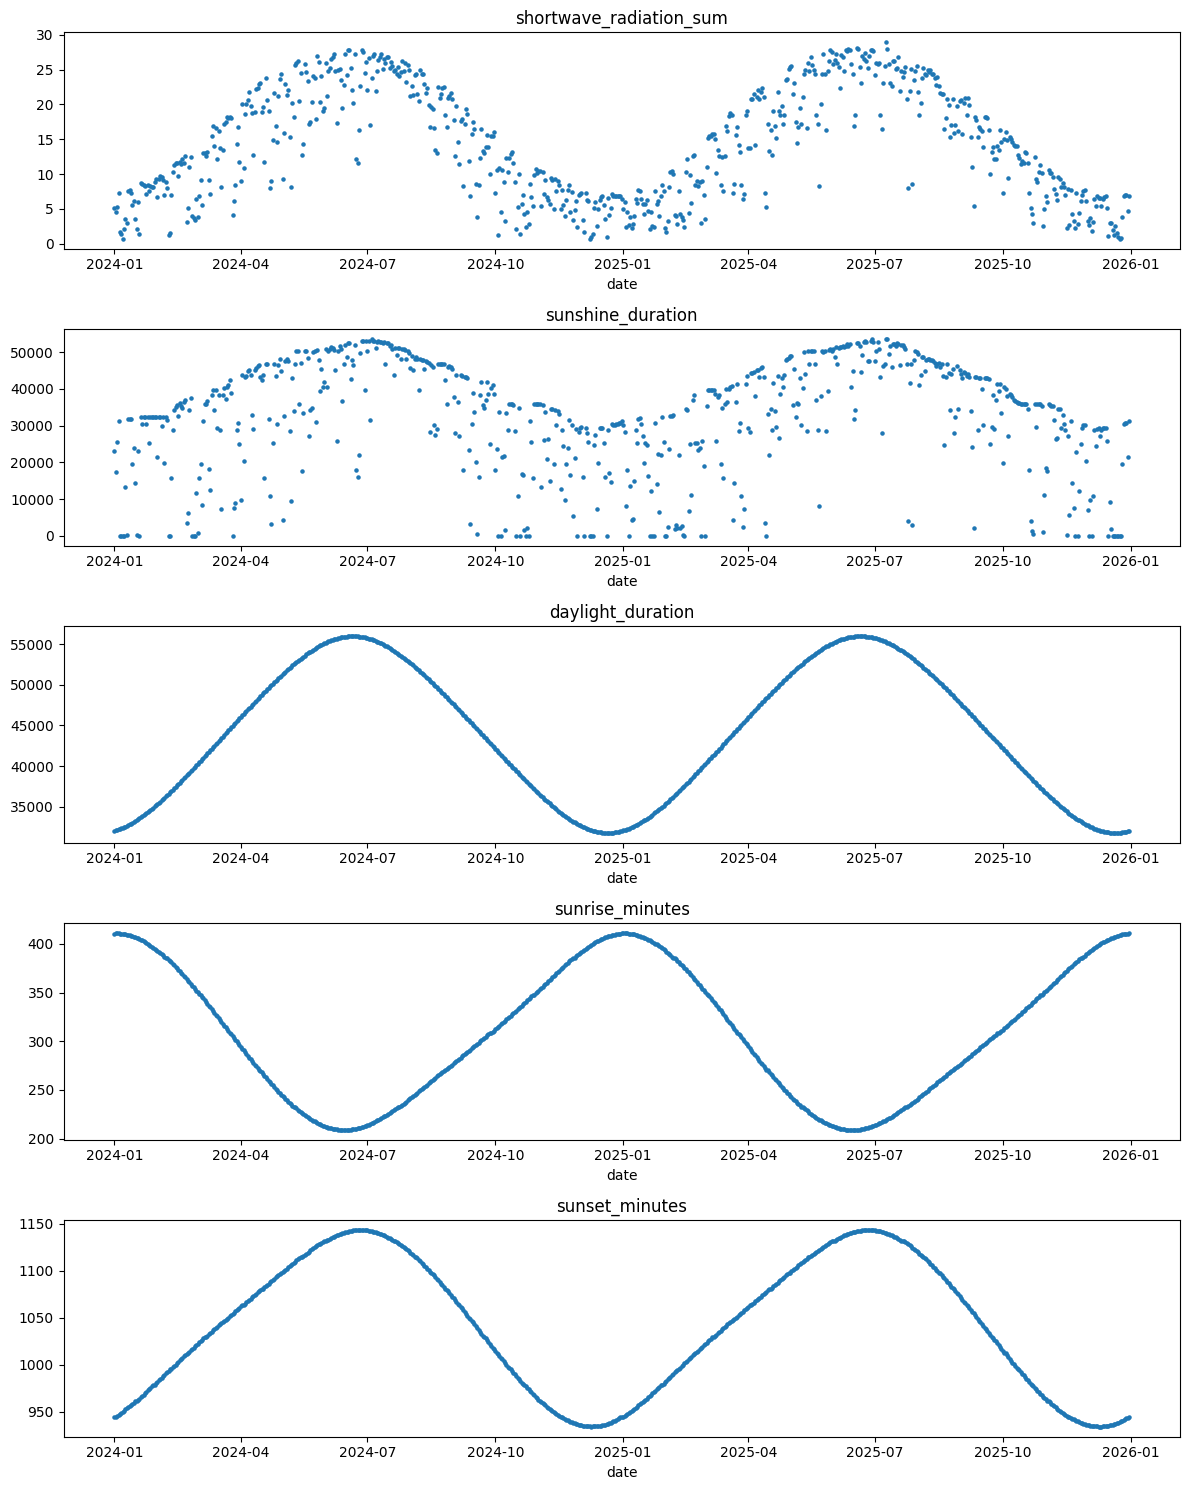

In [40]:
rad_cols = groups['radiation_sunlight']

fig, axes = plt.subplots(len(rad_cols), 1, figsize=(12, len(rad_cols) * 3))

for i, col in enumerate(rad_cols):
    axes[i].scatter(daily_df['date'], daily_df[col], s=5)
    axes[i].set_title(col)
    axes[i].set_xlabel('date')

plt.tight_layout()
plt.show()

Gruppo radiation sunlight non presenta outliers

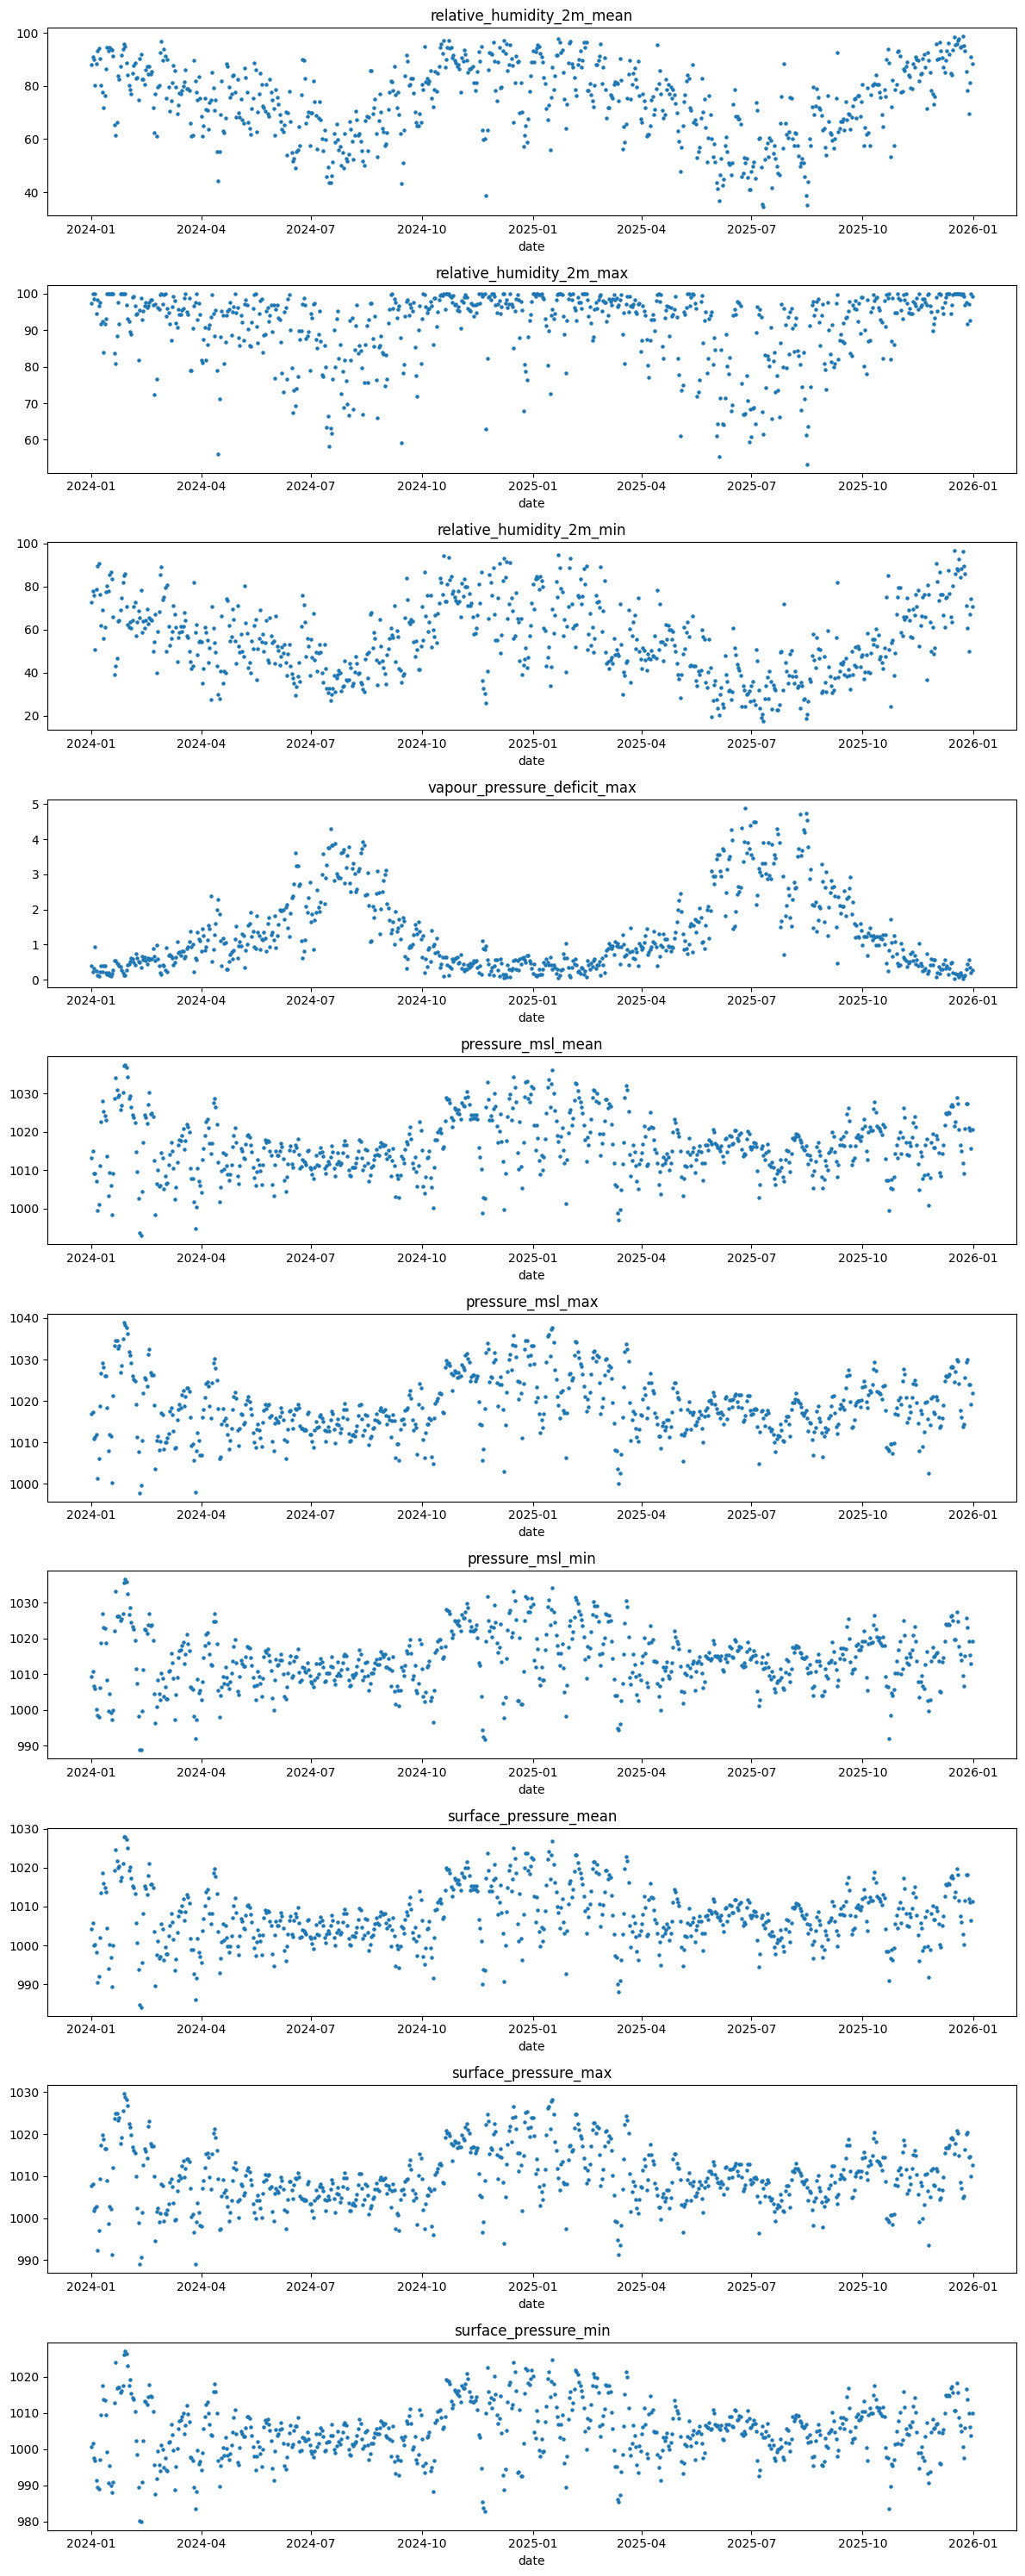

In [41]:
dew_cols = groups['dew_pressure']

fig, axes = plt.subplots(len(dew_cols), 1, figsize=(12, len(dew_cols) * 3))

for i, col in enumerate(dew_cols):
    axes[i].scatter(daily_df['date'], daily_df[col], s=5)
    axes[i].set_title(col)
    axes[i].set_xlabel('date')

plt.tight_layout()
plt.show()

Gruppo dew points non presenta outliers

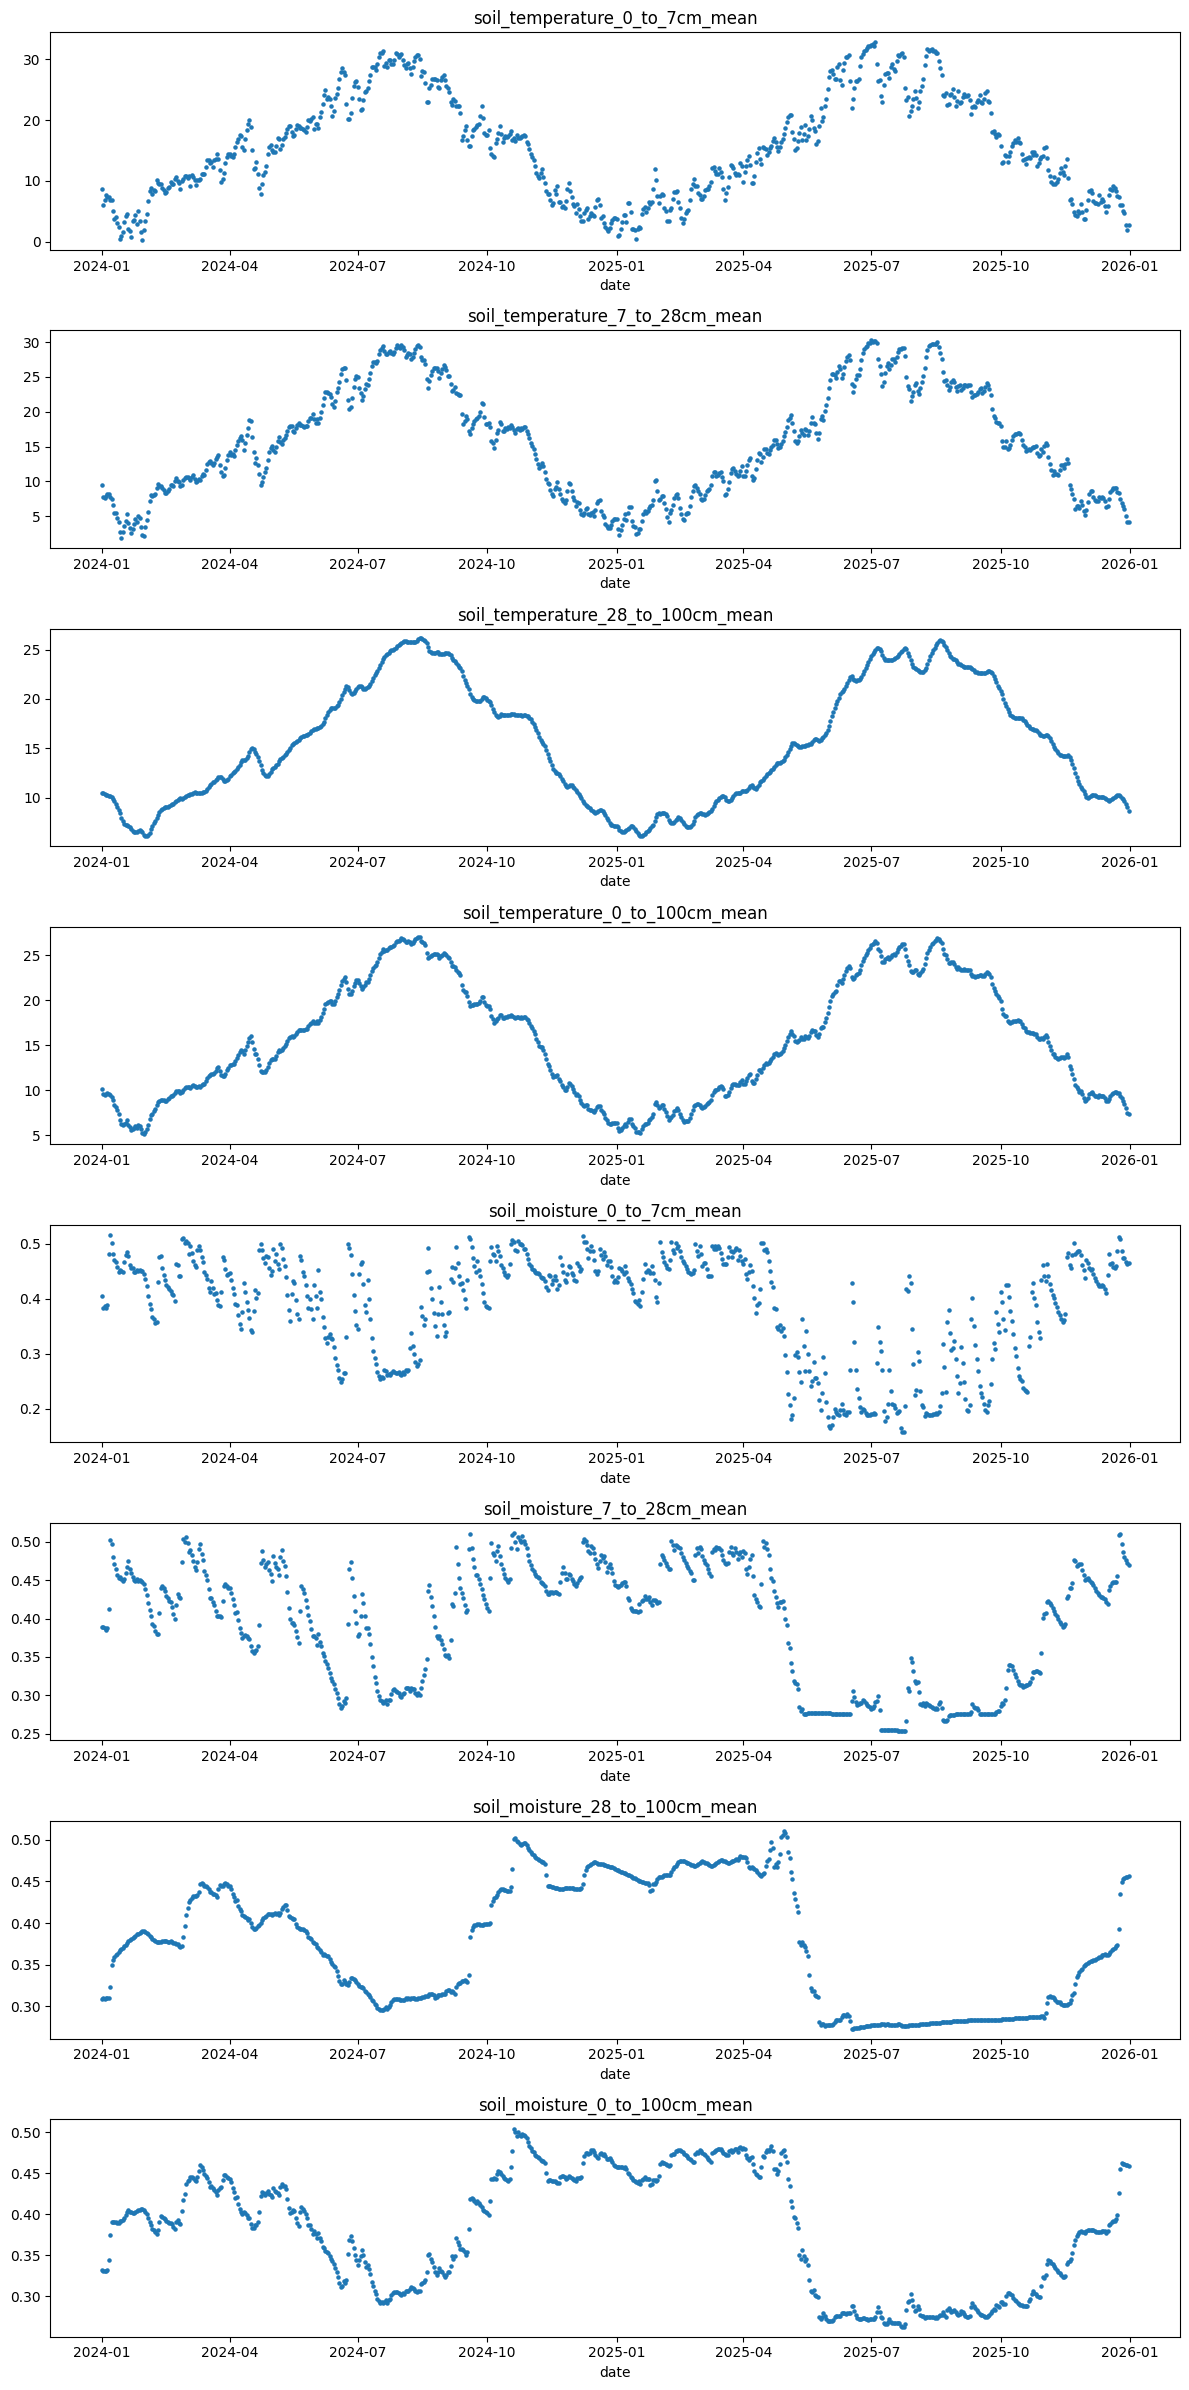

In [42]:
soil_cols = groups['soil']

fig, axes = plt.subplots(len(soil_cols), 1, figsize=(12, len(soil_cols) * 3))

for i, col in enumerate(soil_cols):
    axes[i].scatter(daily_df['date'], daily_df[col], s=5)
    axes[i].set_title(col)
    axes[i].set_xlabel('date')

plt.tight_layout()
plt.show()

Gruppo soil non presenta outliers

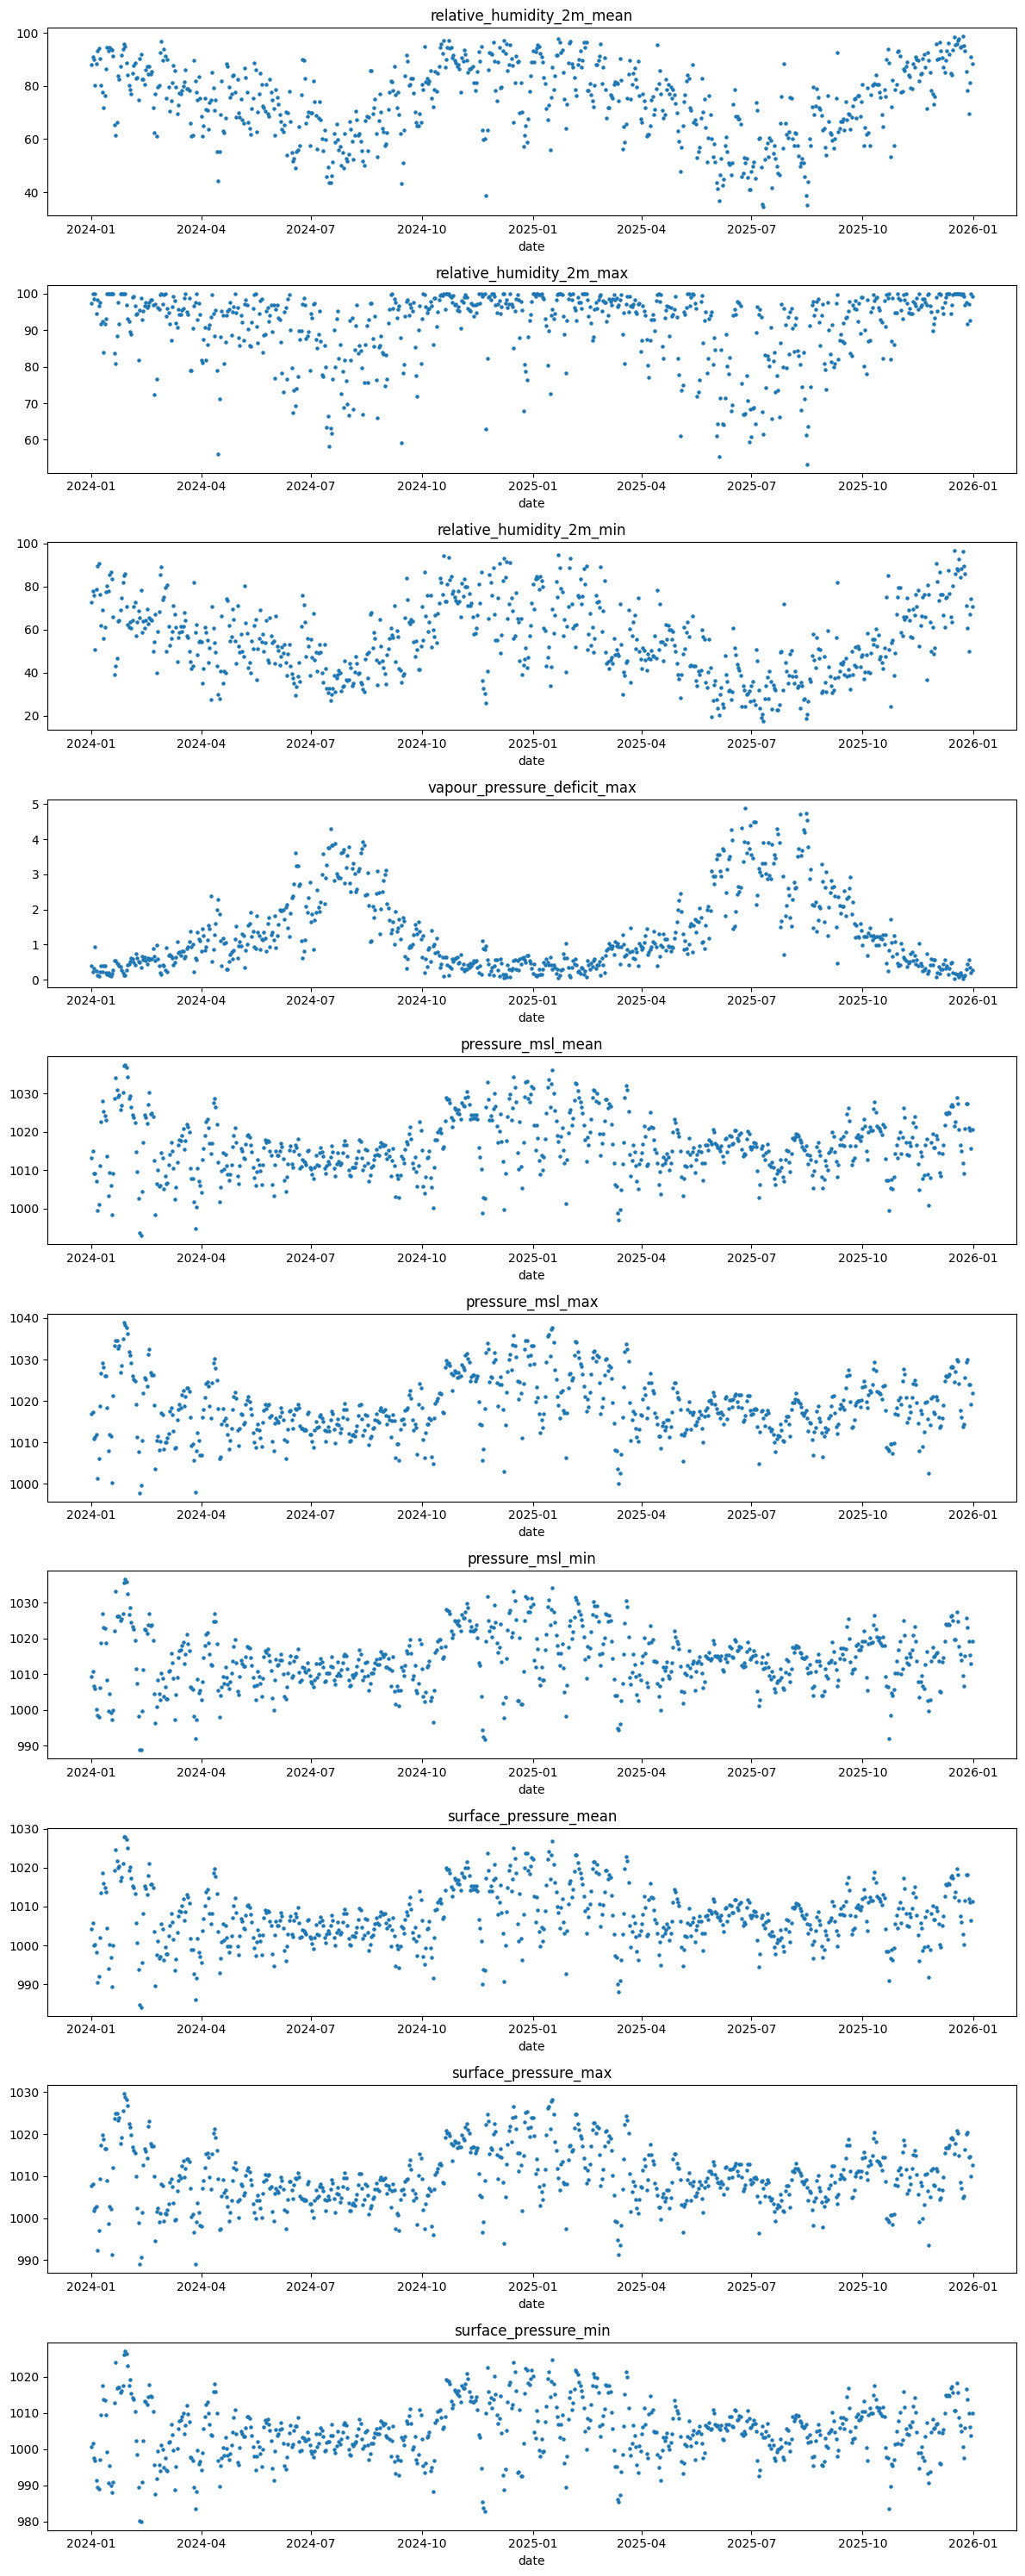

In [43]:
dew_cols = groups['dew_pressure']

fig, axes = plt.subplots(len(dew_cols), 1, figsize=(12, len(dew_cols) * 3))

for i, col in enumerate(dew_cols):
    axes[i].scatter(daily_df['date'], daily_df[col], s=5)
    axes[i].set_title(col)
    axes[i].set_xlabel('date')

plt.tight_layout()
plt.show()

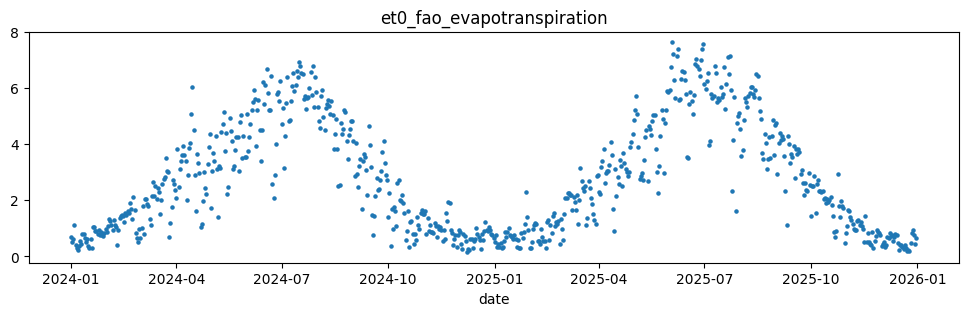

In [44]:

evo_cols = groups['evotraspiration']

fig, axes = plt.subplots(len(evo_cols), 1, figsize=(12, len(evo_cols) * 3), squeeze=False)

for i, col in enumerate(evo_cols):
    axes[i][0].scatter(daily_df['date'], daily_df[col], s=5)
    axes[i][0].set_title(col)
    axes[i][0].set_xlabel('date')

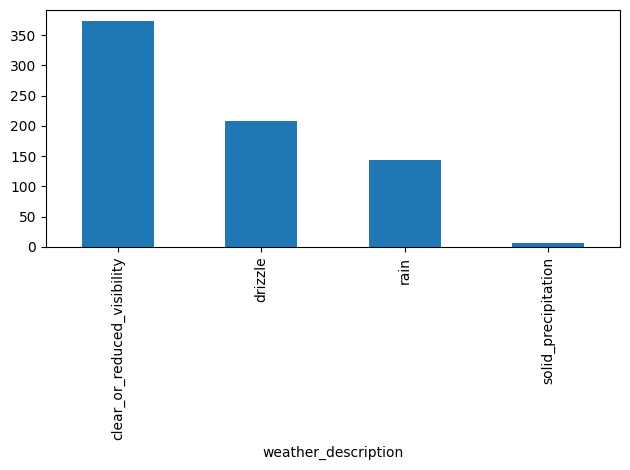

In [45]:
daily_df['weather_description'].value_counts().plot(kind='bar')
plt.tight_layout()
plt.show()

# ESPORTO IL DF CONTENENTE I DATI METEO (DAILY_DF)

In [46]:
data_dir = os.path.join("..", "data")

In [47]:
daily_df.to_parquet(os.path.join(data_dir,"daily_df.parquet"))